# Importing the Essentials

In [175]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# Importing Dataset

In [176]:
df = pd.read_csv("t20_cricket_match_score_prediction.csv")

df.head(10)

,Match ID,Overs Played,Wickets Lost,Run Rate,Home/Away,Opponent Strength,Pitch Condition,Weather,Predicted Score
0,1,7,1,11.04,Away,3,Bowling,Sunny,82
1,2,20,10,11.87,Home,5,Bowling,Sunny,204
2,3,15,7,6.14,Home,7,Balanced,Sunny,105
3,4,11,8,8.84,Home,9,Batting,Cloudy,121
4,5,8,0,9.56,Home,2,Balanced,Sunny,104
5,6,7,4,8.69,Home,4,Bowling,Overcast,55
6,7,19,7,6.21,Home,7,Balanced,Cloudy,125
7,8,11,10,9.19,Away,1,Bowling,Sunny,92
8,9,11,1,12.51,Home,2,Balanced,Cloudy,159
9,10,4,3,5.71,Away,9,Balanced,Overcast,31


In [177]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Match ID           1500 non-null   int64  
 1   Overs Played       1500 non-null   int64  
 2   Wickets Lost       1500 non-null   int64  
 3   Run Rate           1500 non-null   float64
 4   Home/Away          1500 non-null   str    
 5   Opponent Strength  1500 non-null   int64  
 6   Pitch Condition    1500 non-null   str    
 7   Weather            1500 non-null   str    
 8   Predicted Score    1500 non-null   int64  
dtypes: float64(1), int64(5), str(3)
memory usage: 105.6 KB


In [178]:
df.describe()

,Match ID,Overs Played,Wickets Lost,Run Rate,Opponent Strength,Predicted Score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,10.255333,4.894000,9.964173,5.499333,112.637333
std,433.157015,5.864219,3.078487,2.880189,2.891293,71.886356
min,1.000000,1.000000,0.000000,5.000000,1.000000,6.000000
25%,375.750000,5.000000,2.000000,7.507500,3.000000,56.000000
50%,750.500000,10.000000,5.000000,9.915000,6.000000,97.000000
75%,1125.250000,15.000000,8.000000,12.480000,8.000000,157.000000
max,1500.000000,20.000000,10.000000,15.000000,10.000000,382.000000


# Feature Engineering

In [179]:
df.isnull().sum()

Match ID             0
Overs Played         0
Wickets Lost         0
Run Rate             0
Home/Away            0
Opponent Strength    0
Pitch Condition      0
Weather              0
Predicted Score      0
dtype: int64

In [180]:
df.duplicated().sum()

np.int64(0)

In [181]:
df.head(10)

,Match ID,Overs Played,Wickets Lost,Run Rate,Home/Away,Opponent Strength,Pitch Condition,Weather,Predicted Score
0,1,7,1,11.04,Away,3,Bowling,Sunny,82
1,2,20,10,11.87,Home,5,Bowling,Sunny,204
2,3,15,7,6.14,Home,7,Balanced,Sunny,105
3,4,11,8,8.84,Home,9,Batting,Cloudy,121
4,5,8,0,9.56,Home,2,Balanced,Sunny,104
5,6,7,4,8.69,Home,4,Bowling,Overcast,55
6,7,19,7,6.21,Home,7,Balanced,Cloudy,125
7,8,11,10,9.19,Away,1,Bowling,Sunny,92
8,9,11,1,12.51,Home,2,Balanced,Cloudy,159
9,10,4,3,5.71,Away,9,Balanced,Overcast,31


In [182]:
df.select_dtypes(include="object").columns

C:\Users\User\AppData\Local\Temp\ipykernel_2712\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['Home/Away', 'Pitch Condition', 'Weather'], dtype='str')

In [183]:
X = df.drop("Predicted Score", axis=1)

y = df["Predicted Score"]

In [184]:
categorical_cols = X.select_dtypes(
    include="object"
).columns

print(categorical_cols)

Index(['Home/Away', 'Pitch Condition', 'Weather'], dtype='str')


C:\Users\User\AppData\Local\Temp\ipykernel_2712\2888654001.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [185]:
from sklearn.preprocessing import OrdinalEncoder

pitch_order = [
    ["Bowling", "Balanced", "Batting"]
]

encoder = OrdinalEncoder(
    categories=pitch_order
)

df["Pitch Condition"] = encoder.fit_transform(
    df[["Pitch Condition"]]
)

In [186]:
df


,Match ID,Overs Played,Wickets Lost,Run Rate,Home/Away,Opponent Strength,Pitch Condition,Weather,Predicted Score
0,1,7,1,11.04,Away,3,0.0,Sunny,82
1,2,20,10,11.87,Home,5,0.0,Sunny,204
2,3,15,7,6.14,Home,7,1.0,Sunny,105
3,4,11,8,8.84,Home,9,2.0,Cloudy,121
4,5,8,0,9.56,Home,2,1.0,Sunny,104
...,...,...,...,...,...,...,...,...,...
1495,1496,15,8,9.82,Home,3,0.0,Overcast,113
1496,1497,2,10,13.41,Home,9,1.0,Sunny,29
1497,1498,3,6,7.21,Home,1,2.0,Overcast,40
1498,1499,17,6,8.81,Away,5,0.0,Overcast,116


In [187]:
df = pd.get_dummies(
    df,
    columns=["Weather"],
    drop_first=False
)

In [188]:
df

,Match ID,Overs Played,Wickets Lost,Run Rate,Home/Away,Opponent Strength,Pitch Condition,Predicted Score,Weather_Cloudy,Weather_Overcast,Weather_Sunny
0,1,7,1,11.04,Away,3,0.0,82,False,False,True
1,2,20,10,11.87,Home,5,0.0,204,False,False,True
2,3,15,7,6.14,Home,7,1.0,105,False,False,True
3,4,11,8,8.84,Home,9,2.0,121,True,False,False
4,5,8,0,9.56,Home,2,1.0,104,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,15,8,9.82,Home,3,0.0,113,False,True,False
1496,1497,2,10,13.41,Home,9,1.0,29,False,False,True
1497,1498,3,6,7.21,Home,1,2.0,40,False,True,False
1498,1499,17,6,8.81,Away,5,0.0,116,False,True,False


In [189]:
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [190]:
df

,Match ID,Overs Played,Wickets Lost,Run Rate,Home/Away,Opponent Strength,Pitch Condition,Predicted Score,Weather_Cloudy,Weather_Overcast,Weather_Sunny
0,1,7,1,11.04,Away,3,0.0,82,0,0,1
1,2,20,10,11.87,Home,5,0.0,204,0,0,1
2,3,15,7,6.14,Home,7,1.0,105,0,0,1
3,4,11,8,8.84,Home,9,2.0,121,1,0,0
4,5,8,0,9.56,Home,2,1.0,104,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,15,8,9.82,Home,3,0.0,113,0,1,0
1496,1497,2,10,13.41,Home,9,1.0,29,0,0,1
1497,1498,3,6,7.21,Home,1,2.0,40,0,1,0
1498,1499,17,6,8.81,Away,5,0.0,116,0,1,0


In [191]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Home/Away"] = encoder.fit_transform(df["Home/Away"])

In [192]:
df

,Match ID,Overs Played,Wickets Lost,Run Rate,Home/Away,Opponent Strength,Pitch Condition,Predicted Score,Weather_Cloudy,Weather_Overcast,Weather_Sunny
0,1,7,1,11.04,0,3,0.0,82,0,0,1
1,2,20,10,11.87,1,5,0.0,204,0,0,1
2,3,15,7,6.14,1,7,1.0,105,0,0,1
3,4,11,8,8.84,1,9,2.0,121,1,0,0
4,5,8,0,9.56,1,2,1.0,104,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,15,8,9.82,1,3,0.0,113,0,1,0
1496,1497,2,10,13.41,1,9,1.0,29,0,0,1
1497,1498,3,6,7.21,1,1,2.0,40,0,1,0
1498,1499,17,6,8.81,0,5,0.0,116,0,1,0


In [193]:
X = df.drop("Predicted Score", axis=1)

y = df["Predicted Score"]

In [194]:
df.drop (columns=, axis=1, inplace=True)

SyntaxError: expected argument value expression (104215329.py, line 1)

## Skewness and Kurtosis Checking

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

# Calculate skewness
skewness = df[numeric_cols].skew()

# Calculate kurtosis
kurtosis = df[numeric_cols].kurtosis()

result = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

print(result)

                   Skewness  Kurtosis
Match ID           0.000000 -1.200000
Overs Played       0.037554 -1.257245
Wickets Lost       0.021942 -1.176300
Run Rate           0.004770 -1.195026
Home/Away         -0.005339 -2.002643
Opponent Strength  0.009806 -1.211754
Pitch Condition    0.049241 -1.509734
Predicted Score    0.877995  0.388845
Weather_Cloudy     0.795662 -1.368749
Weather_Overcast   0.785709 -1.384509
Weather_Sunny      0.550946 -1.698726


## Nomalize Checking

In [ ]:
from scipy.stats import shapiro

for col in numeric_cols:
    data = df[col].dropna()

    stat, p = shapiro(data)

    print(f"{col}")
    print(f"Statistic = {stat:.4f}")
    print(f"p-value   = {p:.4f}")
    print()

Match ID
Statistic = 0.9548
p-value   = 0.0000

Overs Played
Statistic = 0.9434
p-value   = 0.0000

Wickets Lost
Statistic = 0.9440
p-value   = 0.0000

Run Rate
Statistic = 0.9556
p-value   = 0.0000

Home/Away
Statistic = 0.6366
p-value   = 0.0000

Opponent Strength
Statistic = 0.9346
p-value   = 0.0000

Pitch Condition
Statistic = 0.7916
p-value   = 0.0000

Predicted Score
Statistic = 0.9360
p-value   = 0.0000

Weather_Cloudy
Statistic = 0.5850
p-value   = 0.0000

Weather_Overcast
Statistic = 0.5862
p-value   = 0.0000

Weather_Sunny
Statistic = 0.6105
p-value   = 0.0000



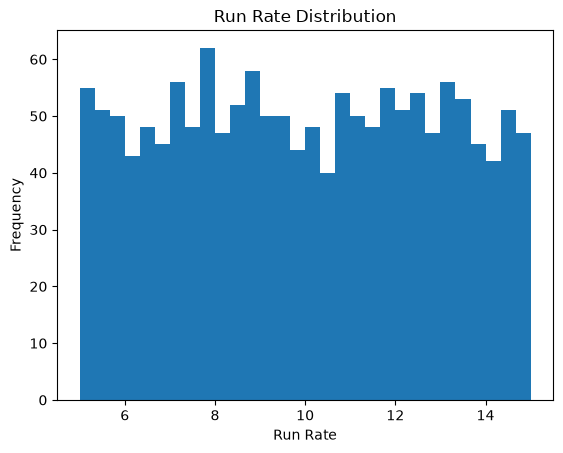

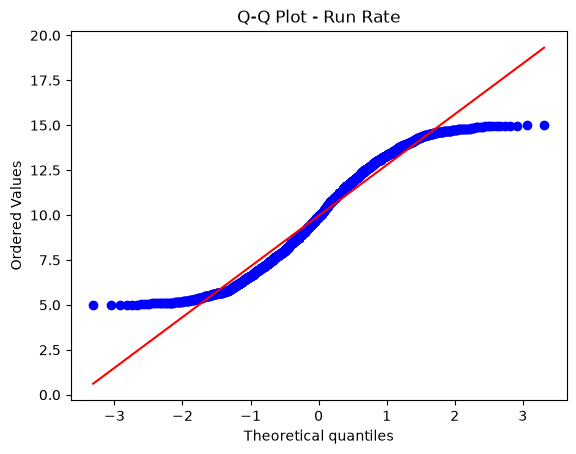

In [ ]:
import scipy.stats as stats

# Histogram
plt.hist(df["Run Rate"], bins=30)
plt.xlabel("Run Rate")
plt.ylabel("Frequency")
plt.title("Run Rate Distribution")
plt.show()

# Q-Q plot
stats.probplot(df["Run Rate"].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot - Run Rate")
plt.show()

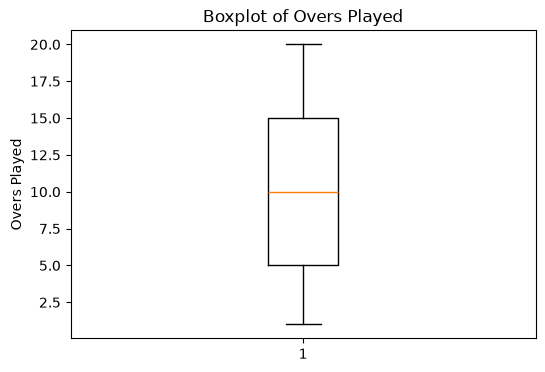

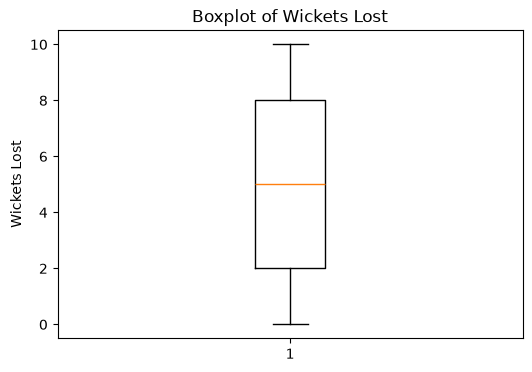

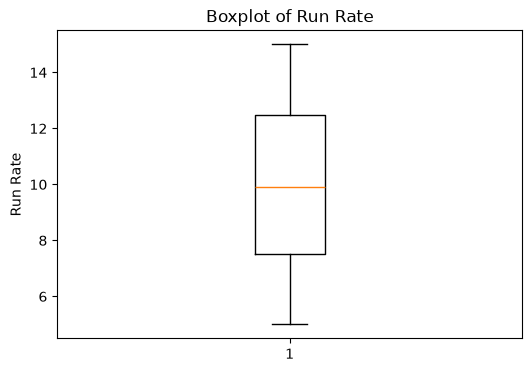

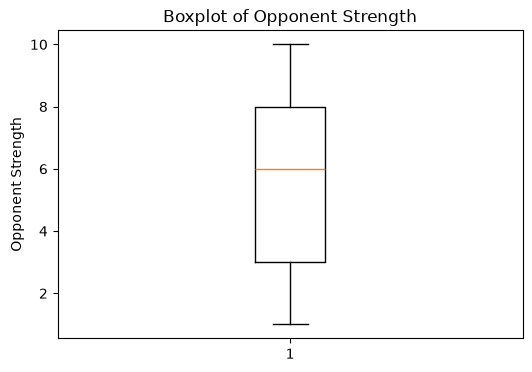

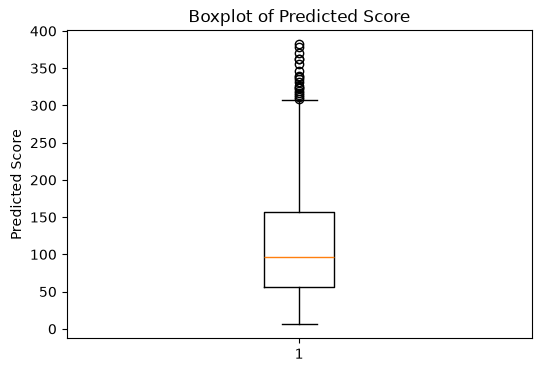

In [ ]:
numeric_cols = [
    "Overs Played",
    "Wickets Lost",
    "Run Rate",
    "Opponent Strength",
    "Predicted Score"
]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

## Checking Outliers

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Overs Played: 0 outliers
Wickets Lost: 0 outliers
Run Rate: 0 outliers
Opponent Strength: 0 outliers
Predicted Score: 19 outliers
